# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [79]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [81]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [82]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [83]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [84]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [85]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [86]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [87]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [88]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [89]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

---
***Recomendaciones***
En el dataset users se observan valores faltantes en las columnas:
- churn_date (88.35%) representan a clientes que siguen activos, la diferencia (11.65%) son usuarios que dejaron de ser clientes, por lo que se pueden dejar como nulos debido a que en algún momento fueron clientes activos.
- city (11.72%) en este caso si es importante investigar para imputar, ya que el porcentaje es significativo.

En el dataset usage se observan valores faltantes en las columnas:
- duration (55.19%) representan a clientes que realizan llamadas, por lo que se recominda ignorar.
- length (44.74%) representan a clientes que prefieren mensajes de texto, por lo que se recominda ignorar.
- date (0.12%) es un porcentaje mínimo, por lo que se pueden dejar como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [90]:
# explorar columnas numéricas de users
col_num_users=["user_id","age"]
print("Resumen estadístico users:")
print(users[col_num_users].describe())

Resumen estadístico users:
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`: Comportamiento de la columna normal, ya que los usuarios inician con id en 10000 y terminan en 13999.
- La columna `age`: En este caso se observa presencias de outliers.

In [91]:
# explorar columnas numéricas de usage
col_num_usage=["id","user_id","duration","length"]
print("Resumen estadístico usage:")
print(usage[col_num_usage].describe())

Resumen estadístico usage:
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`: Columnas con comportamiento normal.
- Las columnas ´duration´ y ´length´: Desviación baja, valores consistentes.

In [92]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city`: Tenemos 3531 registros, 7 ciudades de las cuales la más frecuente es Bogotá.
- La columna `plan`: Tenemos 4000 registros, 2 tipos de plan de los cuales el más contratado es el Basico.

In [93]:
# explorar columna categórica de usage
print(usage['type'].describe())


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type`: Tenemos 40000 registros, 2 tipos de uso de los cuales el más frecuente es texto.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
city y age.
- ¿Qué acción tomarías?
En la columna city revisar si los faltantes dependen de otras variables, para complementar los registros.
En la columna age estandarizar los sentinels con la media.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [94]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors="coerce")

In [95]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")

In [96]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'] = users['reg_date'].dt.year
print(users['reg_date'].nunique())
print(users['reg_date'].value_counts())

4
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, tenemos 40 registros con valores futuros.

In [97]:
# Revisar los años presentes en `date` de usage
usage['date'] = usage['date'].dt.year
print(usage['date'].nunique())
print(usage['date'].value_counts())

1
2024.0    39950
Name: date, dtype: int64


En `date`, tenemos 39950 registros con la fecha a analizar 2024.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Si, tenemos 40 registros con valores futuros.
- ¿Qué harías con ellas?
Dado que hay pocos ausentes y para no inventar fechas falsas para estos registros, los eliminamos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [98]:
# Reemplazar -999 por la mediana de age

age_mediana = users['age'].replace(-999,pd.NA).median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [99]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [100]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].replace(2026,pd.NA)

# Verificar cambios
users['reg_date'].describe()

count     3960
unique       3
top       2024
freq      1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [101]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [102]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Diagnostico de nulos en `duration` y `length`: Si es MAR, por lo que se quedan como nulos. ya que la ausencia depende de otra variable.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [103]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,id,date,duration,length,is_text,is_call
0,10000,236778,20240.0,23.70,258.0,7,3
1,10001,296458,30360.0,33.18,226.0,5,10
2,10002,111444,14168.0,10.74,225.0,5,2


In [104]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={
    'is_text':'cant_mensajes',
    'is_call':'cant_llamadas',
    'duration':'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,id,date,cant_minutos_llamada,length,cant_mensajes,cant_llamadas
0,10000,236778,20240.0,23.70,258.0,7,3
1,10001,296458,30360.0,33.18,226.0,5,10
2,10002,111444,14168.0,10.74,225.0,5,2


In [105]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg,users,on=['user_id'],how='inner')
user_profile.head(5)

,user_id,id,date,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,236778,20240.0,23.70,258.0,7,3,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN
1,10001,296458,30360.0,33.18,226.0,5,10,Mateo,Torres,53.0,<NA>,2022,Basico,NaN
2,10002,111444,14168.0,10.74,225.0,5,2,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN
3,10003,289686,28336.0,8.99,530.0,11,3,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN
4,10004,199943,14168.0,8.01,229.0,4,3,Mateo,Torres,63.0,GDL,2022,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [106]:
# Resumen estadístico de las columnas numéricas
columnas_numericas=['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
print(user_profile[columnas_numericas].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  3999.000000    3999.000000    3999.000000           3999.000000
mean     48.138285       5.524381       4.478120             23.317054
std      17.691541       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [107]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True))

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

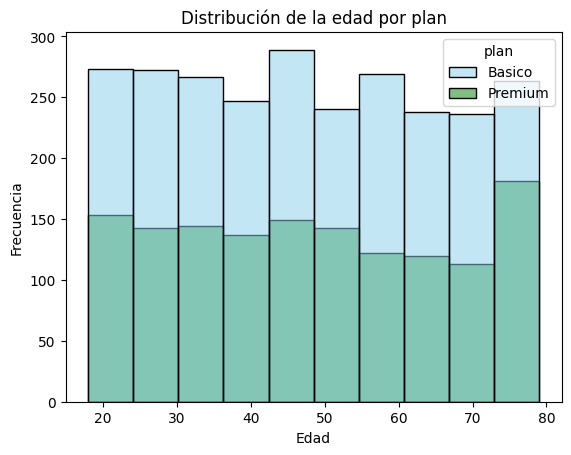

In [108]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de la edad por plan')
plt.show()

💡Insights: 
- Distribución simétrica, la edad por plan muestra que las personas entre 40 y 50 años prefieren el plan básico, mientras que personas de entre 70 y 80 años prefieren un plan Premium.

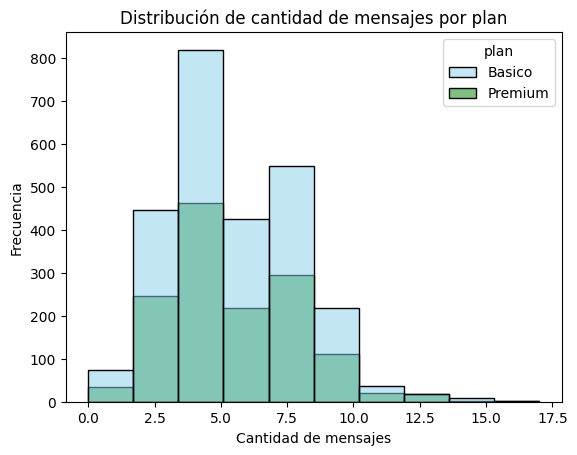

In [109]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.title('Distribución de cantidad de mensajes por plan')
plt.show()

💡Insights: 
- En esta distibución simétrica de cantidad de mensajes por plan, nos muestra que se uliliza más el plan Básico para el envío de mensajes, mientras que en el plan Pemium no sucede.

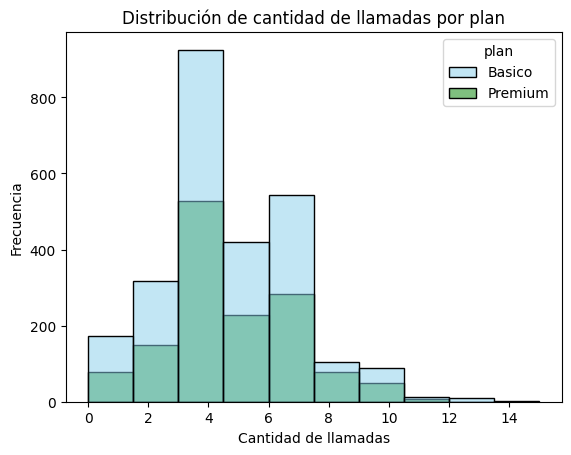

In [110]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribución de cantidad de llamadas por plan')
plt.show()

💡Insights: 
- Distribución simétrica y variaciones normales en la frecuencia de cantidad de llamadas, aunque siguen usando el plan Básico para realizar llamadas que en el plan Premium.

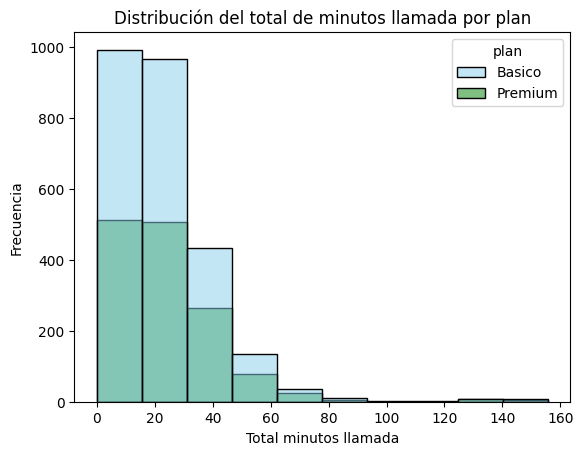

In [111]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel('Total minutos llamada')
plt.ylabel('Frecuencia')
plt.title('Distribución del total de minutos llamada por plan')
plt.show()

💡Insights: 
- Aquí vemos una distribución con sesgo a la derecha, lo que representa que se realizan más llamadas cortas en ambos planes Básico y Prémium. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

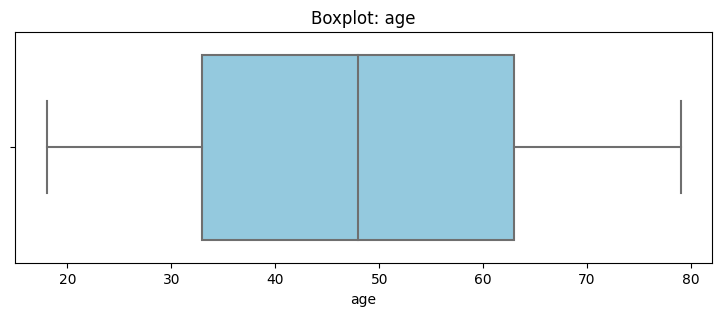

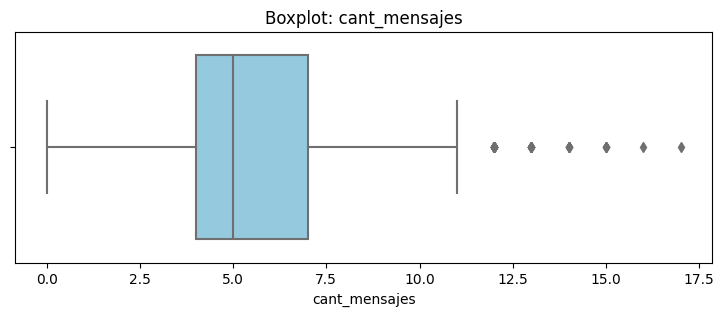

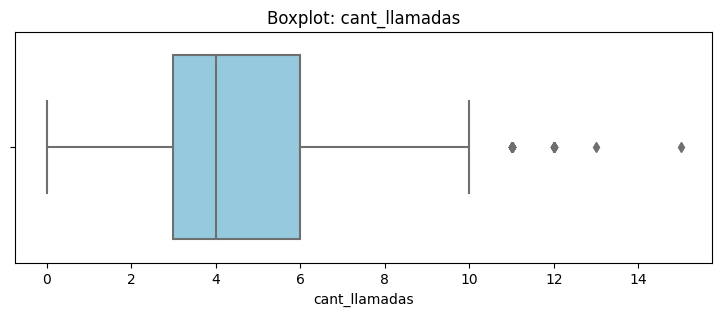

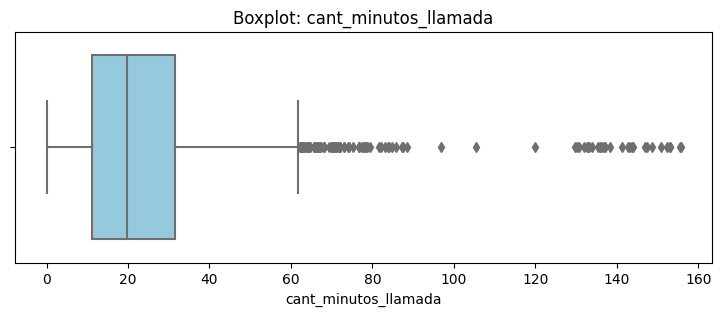

In [112]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

💡Insights: 
- Age: No presenta outliers.
- cant_mensajes: Si presenta outliers.
- cant_llamadas: Si presenta outliers.
- cant_minutos_llamada: Si presenta outliers.

In [113]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    print(col,"IQR:",IQR)



cant_mensajes IQR: 3.0
cant_llamadas IQR: 3.0
cant_minutos_llamada IQR: 20.295


In [114]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantenemos outliers ya que representa un comportamiento real de alto valor.
- cant_llamadas: mantener o no outliers, porqué? Mantenemos outliers ya que representa un comportamiento real de alto valor.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantenemos outliers ya que representa un comportamiento real de alto valor.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [115]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas']<5) & (user_profile['cant_mensajes']<5),
    (user_profile['cant_llamadas']<10) & (user_profile['cant_mensajes']<10)]
valores = ['Bajo uso','Uso medio']
user_profile['grupo_uso']=np.select(condiciones, valores, default='Alto uso')

In [116]:
# verificar cambios
user_profile.head()

,user_id,id,date,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,236778,20240.0,23.70,258.0,7,3,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,Uso medio
1,10001,296458,30360.0,33.18,226.0,5,10,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,Alto uso
2,10002,111444,14168.0,10.74,225.0,5,2,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,Uso medio
3,10003,289686,28336.0,8.99,530.0,11,3,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,Alto uso
4,10004,199943,14168.0,8.01,229.0,4,3,Mateo,Torres,63.0,GDL,2022,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [117]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age']<30),
    (user_profile['age']<60)]
valores = ['Joven','Adulto']
user_profile['grupo_edad']=np.select(condiciones, valores, default='Adulto Mayor')

In [118]:
# verificar cambios
user_profile.head()

,user_id,id,date,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,236778,20240.0,23.70,258.0,7,3,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,Uso medio,Adulto
1,10001,296458,30360.0,33.18,226.0,5,10,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,Alto uso,Adulto
2,10002,111444,14168.0,10.74,225.0,5,2,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,Uso medio,Adulto
3,10003,289686,28336.0,8.99,530.0,11,3,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,Alto uso,Adulto Mayor
4,10004,199943,14168.0,8.01,229.0,4,3,Mateo,Torres,63.0,GDL,2022,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

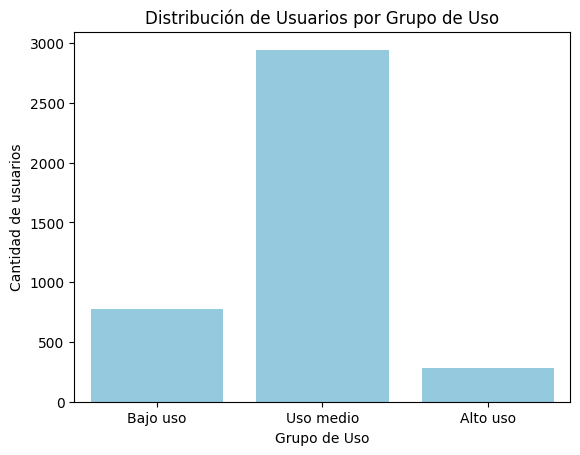

In [122]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x='grupo_uso', color='skyblue',order=['Bajo uso','Uso medio','Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

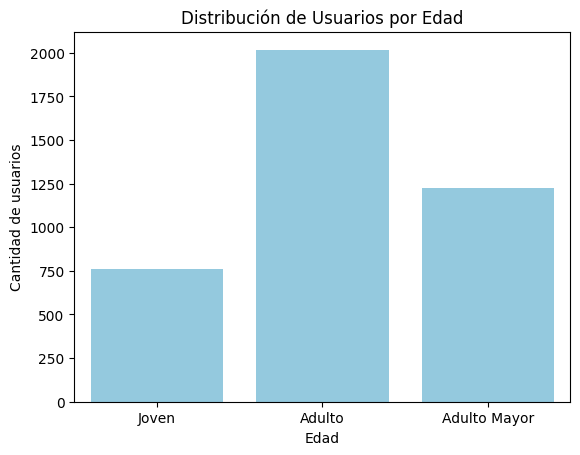

In [123]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad', color='skyblue',order=['Joven','Adulto','Adulto Mayor'])
plt.title('Distribución de Usuarios por Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
En la limpieza de valores sucios se encontraron datos con valores futuros en las fechas (0.12%), valores faltantes en cuidades (11.72%) y valores imposibles en edades, por lo que se rellenaron con Nan para no perder datos.
Se detectó una mayor contratación y uso tanto de llamadas como mensajes del plan Básico en clientes de entre 40 y 50 años, mientras que en el plan Premium las edades que más lo consumen son adultos mayores.
Los segmentos más valiosos para la empresa, como área de oportunidad es el uso, mejorando los planes.
Los outliers encontrados no fueron muy extremos, por lo que se mantuvieron ya que son valores altos reales.
Se podrían mejorar los planes como el Premium con promociones para captar clientes de edades jovénes y adultas.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Datos con valores faltantes
- Datos con valores atípicos
- Datos con valores futuros


🔍 **Segmentos por Edad**
- Menos contrataciones en edades jóvenes


📊 **Segmentos por Nivel de Uso**
- Baja cantidad de usuarios tienen alto uso del servicio 
- Baja cantidad de usuarios tienen bajo uso del servicio


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Mejorar el plan Premium para captar clientes jóvenes, con promociones atractivas y costos no excesivos.
- Mejorar el servicio en ambos planes para captar un mayor uso por los usuarios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`